In [1]:
import pandas as pd




df = pd.read_csv('reviews.csv')


df

,reviews,sentiment
0,Tabreez offers a great selection of fish cooke...,positive
1,Tabreez Restaurant is widely considered one of...,positive
2,It’s an amazing place for seafood lovers and I...,positive
3,Very good see food at a reasonable price. The ...,positive
4,This restaurant is easily one of the best if y...,positive
...,...,...
195,My cousin says beef shawarma was good with str...,positive
196,It's only them who is located on the opposite ...,neutral
197,This legendary shawarma spot has been serving ...,positive
198,Tried the mixed meat shawarma and really enjoy...,positive


In [2]:
models = ["cardiffnlp/twitter-roberta-base-sentiment-latest", "finiteautomata/bertweet-base-sentiment-analysis", "nlptown/bert-base-multilingual-uncased-sentiment"]




# Pretrained Model Challenge — Bahrain Visitor-Review Analyzer

## Step 1 — Define the problem

**Problem:** A client (a tourism-tech company in Bahrain) receives thousands of visitor
reviews about restaurants, cafés and attractions. They want an AI system that reads a
review and answers three questions:

1. **Sentiment** — is the review positive, negative or neutral?
2. **Topic** — what is the review mainly about: food quality, service, price, location or ambience?
3. **Summary** — can a long review be shortened automatically?

**Who uses it:** customer-experience analysts and marketing staff — non-ML people, so the
system must be a simple app, not a research notebook.

**Input:** free English text (often informal, sometimes with Arabic loanwords like *inshallah*).

**Output:** a label + confidence score for sentiment, a topic label, and a short summary.
Every prediction dictionary must additionally carry the custom metadata key
`{'metadata': 'huggingface_AI_model'}`.

**Success criteria:** macro-F1 ≥ 0.6 on sentiment (because the classes are imbalanced —
143 positive / 49 negative / only 8 neutral — plain accuracy would reward a model that
always says "positive"), topic accuracy ≥ 0.5, and total inference time of a few seconds
per review on CPU.

**Strategy:** we do **not** train anything from scratch. We search the Hugging Face Hub for
pretrained models, inspect their model cards, evaluate them on our own 200-review dataset,
investigate their mistakes, and only then decide: use as-is, replace, or adapt (fine-tune).


## Step 2 — Collect and inspect the data

`reviews.csv` contains **200 visitor reviews of Bahrain venues** (restaurants, cafés,
malls, farms, burger joints) collected from public review platforms and **manually labeled**
as `positive` / `negative` / `neutral`. No private or sensitive data is included.

Let us look at the label distribution and text lengths before touching any model.


sentiment
positive    143
negative     49
neutral       8
Name: count, dtype: int64

Review length stats (characters):
count     200.0
mean      343.0
std       326.0
min        22.0
25%       129.0
50%       254.0
75%       442.0
max      2218.0
Name: reviews, dtype: float64

Duplicated reviews: 1


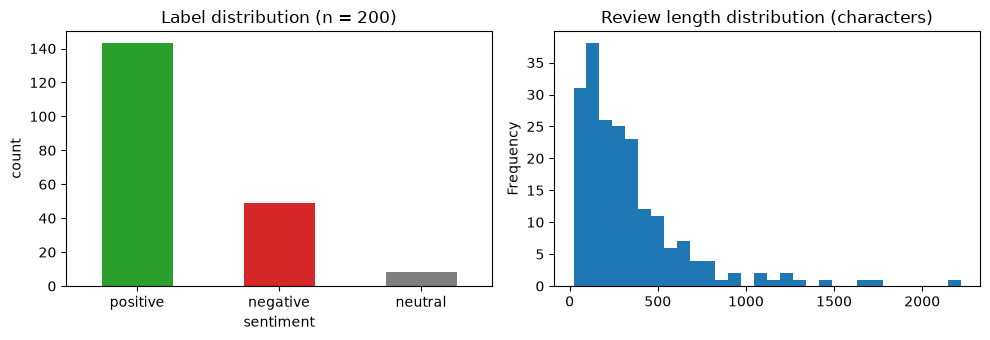

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os

print(df['sentiment'].value_counts())
print()
print('Review length stats (characters):')
print(df['reviews'].str.len().describe().round(0))
print()
print('Duplicated reviews:', df['reviews'].duplicated().sum())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
df['sentiment'].value_counts().reindex(['positive', 'negative', 'neutral']) \
    .plot.bar(ax=axes[0], color=['#2ca02c', '#d62728', '#7f7f7f'], rot=0)
axes[0].set_title('Label distribution (n = 200)')
axes[0].set_xlabel('sentiment')
axes[0].set_ylabel('count')
df['reviews'].str.len().plot.hist(ax=axes[1], bins=30, color='#1f77b4')
axes[1].set_title('Review length distribution (characters)')
plt.tight_layout()
plt.show()


**What this tells us**

- The dataset is **heavily imbalanced** (71.5% positive, 4% neutral) — accuracy is a weak
  metric here, macro-F1 is the honest one.
- Reviews range from 22 characters (`"Old is gold."`) to 2,218 characters, so models must
  handle both very short and very long inputs (we will use truncation for long ones).


## Step 3 — Find pretrained models on the Hugging Face Hub

For **sentiment** we compare three popular models (shortlisted in the cell above):

| | [cardiffnlp/twitter-roberta-base-sentiment-latest](https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest) | [finiteautomata/bertweet-base-sentiment-analysis](https://huggingface.co/finiteautomata/bertweet-base-sentiment-analysis) | [nlptown/bert-base-multilingual-uncased-sentiment](https://huggingface.co/nlptown/bert-base-multilingual-uncased-sentiment) |
|---|---|---|---|
| **Task** | sentiment (negative/neutral/positive) | sentiment (NEG/NEU/POS) | star rating 1–5 |
| **Architecture** | RoBERTa-base, 125M | BERTweet-base, 135M | BERT-base multilingual, 167M |
| **Training data** | ~124M tweets, fine-tuned on TweetEval | BERTweet tweets + SemEval sentiment sets | Yelp / Trustpilot-style 1–5 star reviews in 6 languages |
| **Languages** | English (Twitter style) | English (Twitter style) | en, nl, de, fr, it, es |
| **License** | CC-BY-4.0 | not declared on the card | MIT |
| **Known limits** | expects casual tweet text; formal long reviews may shift domain | same | outputs *stars*, not sentiment — we must map 1–2★→negative, 3★→neutral, 4–5★→positive |

Auxiliary models used later in the lab:

- **Zero-shot topic:** [MoritzLaurer/mDeBERTa-v3-base-mnli-xnli](https://huggingface.co/MoritzLaurer/mDeBERTa-v3-base-mnli-xnli) — DeBERTaV3-base (184M), trained on NLI (MNLI/FEVER/ANLI/XNLI, 100 languages, MIT). We also test the much smaller [typeform/distilbert-base-uncased-mnli](https://huggingface.co/typeform/distilbert-base-uncased-mnli) (67M) for speed.
- **Summarization:** [sshleifer/distilbart-cnn-12-6](https://huggingface.co/sshleifer/distilbart-cnn-12-6) — distilled BART (306M) trained on CNN/DailyMail, Apache-2.0.

The cell below pulls live metadata (author, downloads, license) straight from the Hub —
this is what we check on every model card before using a model.


In [4]:
try:
    from huggingface_hub import model_info

    hub_models = models + [
        'MoritzLaurer/mDeBERTa-v3-base-mnli-xnli',
        'typeform/distilbert-base-uncased-mnli',
        'sshleifer/distilbart-cnn-12-6',
    ]
    rows = []
    for m in hub_models:
        info = model_info(m)
        lic = info.cardData.license if info.cardData else None
        if isinstance(lic, list):
            lic = [x if isinstance(x, str) else getattr(x, 'name', str(x)) for x in lic]
        rows.append({'model': m, 'author': info.author, 'downloads': info.downloads,
                     'likes': info.likes, 'license': lic, 'library': info.library_name})
    pd.DataFrame(rows).sort_values('downloads', ascending=False).reset_index(drop=True)
except Exception as e:
    print('Hub metadata not fetched (offline?) — static model-card table above applies.', e)


## Custom pipeline: the required `{'metadata': 'huggingface_AI_model'}` key

The challenge requires that our pipeline outputs a custom dictionary structure: in addition
to the standard Hugging Face `label` and `score` keys, **every** output dict must carry
`{'metadata': 'huggingface_AI_model'}`.

We implement this by subclassing `transformers.Pipeline` and overriding `__call__`: the
underlying Hugging Face pipeline does all the work (input → tokenizer → model → logits →
label + score) and we append the metadata key to every returned dict — for single inputs
(a `dict`), batch inputs (a `list` of dicts) and `top_k` outputs alike.

Let's define the class and smoke-test it on tricky inputs.


In [5]:
import logging

from transformers import Pipeline, pipeline

# keep the notebook output clean (the LOAD REPORT table is not needed here)
logging.getLogger('transformers.utils.loading_report').setLevel(logging.CRITICAL)


class CustomPipeline(Pipeline):
    """Hugging Face pipeline whose outputs all carry {'metadata': 'huggingface_AI_model'}."""

    def __init__(self, task, model=None, **kwargs):
        self._pipe = pipeline(task, model=model, **kwargs)
        super().__init__(model=self._pipe.model, tokenizer=self._pipe.tokenizer,
                         task=task, device=self._pipe.device)

    def __call__(self, inputs, *args, **kwargs):
        outputs = self._pipe(inputs, *args, **kwargs)
        if isinstance(outputs, dict):
            outputs['metadata'] = 'huggingface_AI_model'
        else:
            for o in outputs:
                if isinstance(o, dict):
                    o['metadata'] = 'huggingface_AI_model'
        return outputs

    def _sanitize_parameters(self, **kwargs):
        return {}, {}, {}

    def preprocess(self, inputs, **kwargs):
        raise NotImplementedError   # never called: __call__ is fully delegated

    def _forward(self, model_inputs, **kwargs):
        raise NotImplementedError   # never called: __call__ is fully delegated

    def postprocess(self, model_outputs, **kwargs):
        raise NotImplementedError   # never called: __call__ is fully delegated


smoke = CustomPipeline('text-classification', model=models[0], device=-1)

tricky_examples = [
    'The food was absolutely delicious!',                                    # clearly positive
    'Worst place ever, the staff ignored us completely.',                     # clearly negative
    'Oh great, another hour waiting for cold food. Just what I wanted.',      # sarcastic
    'The fish was fresh but the service was slow and the price too high.',    # mixed
    'Inshallah the mall will improve, but for now there are no shops.',       # Arabic loanword + hedged
    'Try apple pie with vanilla ice cream 😋',                                # very short + emoji
]

for t in tricky_examples:
    print(f'{t!r}')
    print('   ->', smoke(t))
    print()

print('Batch call keeps the metadata too:')
print(smoke(tricky_examples, batch_size=4, truncation=True, max_length=128)[-1])
print()
print('top_k output also carries it:')
print(smoke(tricky_examples[3], top_k=3))


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


'The food was absolutely delicious!'
   -> [{'label': 'positive', 'score': 0.987141489982605, 'metadata': 'huggingface_AI_model'}]

'Worst place ever, the staff ignored us completely.'


   -> [{'label': 'negative', 'score': 0.9429646730422974, 'metadata': 'huggingface_AI_model'}]

'Oh great, another hour waiting for cold food. Just what I wanted.'
   -> [{'label': 'positive', 'score': 0.37244272232055664, 'metadata': 'huggingface_AI_model'}]

'The fish was fresh but the service was slow and the price too high.'
   -> [{'label': 'negative', 'score': 0.8601620197296143, 'metadata': 'huggingface_AI_model'}]

'Inshallah the mall will improve, but for now there are no shops.'
   -> [{'label': 'neutral', 'score': 0.5366141200065613, 'metadata': 'huggingface_AI_model'}]

'Try apple pie with vanilla ice cream 😋'
   -> [{'label': 'positive', 'score': 0.8616943359375, 'metadata': 'huggingface_AI_model'}]

Batch call keeps the metadata too:


{'label': 'positive', 'score': 0.8616943359375, 'metadata': 'huggingface_AI_model'}

top_k output also carries it:
[{'label': 'negative', 'score': 0.8601620197296143, 'metadata': 'huggingface_AI_model'}, {'label': 'neutral', 'score': 0.13116250932216644, 'metadata': 'huggingface_AI_model'}, {'label': 'positive', 'score': 0.008675392717123032, 'metadata': 'huggingface_AI_model'}]


## Step 4 — Run inference on all 200 reviews

We run every review through all three sentiment models. The pipeline output is a
`{'label': ..., 'score': ..., 'metadata': 'huggingface_AI_model'}` dict; for evaluation
we store label + score per review. Batch processing (`batch_size=16`) + truncation keeps
CPU inference to ~30 s per model. Results are cached in `results/` so re-running the
notebook is fast — delete that folder to force a full recomputation.


In [6]:
import json
import time

LABEL_MAP = {
    models[0]: None,   # already outputs negative / neutral / positive
    models[1]: {'POS': 'positive', 'NEG': 'negative', 'NEU': 'neutral'},
    models[2]: {'1 star': 'negative', '2 stars': 'negative', '3 stars': 'neutral',
                '4 stars': 'positive', '5 stars': 'positive'},
}


def get_predictions(model_id, texts, force=False):
    key = model_id.replace('/', '__')
    cache_path = os.path.join('results', f'preds_{key}.csv')
    if os.path.exists(cache_path) and not force:
        print(f'[cache] {model_id}  (loading saved predictions)')
        return pd.read_csv(cache_path), None

    t0 = time.time()
    pipe = CustomPipeline('text-classification', model=model_id, device=-1)
    t_load = time.time() - t0
    t0 = time.time()
    outs = pipe(texts, batch_size=16, truncation=True, max_length=128)
    t_inf = time.time() - t0
    mapping = LABEL_MAP[model_id]
    rows = []
    for t, y, o in zip(texts, df['sentiment'], outs):
        lab = o['label']
        rows.append({'review': t, 'true': y,
                     'pred': mapping.get(lab, lab) if mapping else lab,
                     'score': o['score']})
    res = pd.DataFrame(rows)
    os.makedirs('results', exist_ok=True)
    res.to_csv(cache_path, index=False)
    meta = {'load_s': round(t_load, 1), 'infer_s': round(t_inf, 1),
            'params_M': round(pipe._pipe.model.num_parameters() / 1e6, 1)}
    print(f'[run] {model_id}: load={meta["load_s"]}s  infer={meta["infer_s"]}s  '
          f'params={meta["params_M"]}M')
    return res, meta


texts = df['reviews'].tolist()
preds, meta = {}, {}
for m in models:
    preds[m], meta[m] = get_predictions(m, texts)

# restore timing info when predictions were loaded from cache
if os.path.exists('results/summary_sentiment.json'):
    with open('results/summary_sentiment.json') as f:
        cached_summary = json.load(f)
    for m in models:
        if meta[m] is None:
            for s in cached_summary:
                if s['model'] == m:
                    meta[m] = {'load_s': s['load_s'], 'infer_s': s['infer_s'],
                               'params_M': s['params_M']}

pd.DataFrame([{'model': m, **meta[m]} for m in models])


[cache] cardiffnlp/twitter-roberta-base-sentiment-latest  (loading saved predictions)
[cache] finiteautomata/bertweet-base-sentiment-analysis  (loading saved predictions)
[cache] nlptown/bert-base-multilingual-uncased-sentiment  (loading saved predictions)


,model,load_s,infer_s,params_M
0,cardiffnlp/twitter-roberta-base-sentiment-latest,6.6,32.3,124.6
1,finiteautomata/bertweet-base-sentiment-analysis,198.4,36.3,134.9
2,nlptown/bert-base-multilingual-uncased-sentiment,228.2,32.9,167.4


In [7]:
# Prove the custom metadata key is present on the real pipeline output
demo = CustomPipeline('text-classification', model=models[0], device=-1)
out = demo('The shawarma was crispy and full of flavour!')
# transformers v5 returns a list even for a single input -> normalize for display
out = out if isinstance(out, dict) else out[0]
print(out)
assert out['metadata'] == 'huggingface_AI_model'
print()
print(demo(['One more batch example for the metadata key.'], batch_size=2, truncation=True))


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{'label': 'positive', 'score': 0.96671462059021, 'metadata': 'huggingface_AI_model'}

[{'label': 'neutral', 'score': 0.8942493796348572, 'metadata': 'huggingface_AI_model'}]


## Step 6 — Evaluate the models

Metrics: **accuracy** (intuitive), **per-class precision / recall / F1**, and **macro-F1**
(the average F1 across the three classes — the right headline metric for an imbalanced
dataset). We also plot confusion matrices to see *where* each model goes wrong.

> ⚠️ Before reading the table: note the suspicious **100%** of the Cardiff model. We will
> come back to it in the error-analysis section — a perfect score on real text is almost
> never honest.


In [8]:
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                               confusion_matrix)

labels3 = ['positive', 'negative', 'neutral']
rows = []
for m in models:
    y, p = df['sentiment'], preds[m]['pred']
    mac = precision_recall_fscore_support(y, p, labels=labels3, average='macro', zero_division=0)
    per = precision_recall_fscore_support(y, p, labels=labels3, zero_division=0)
    rows.append({
        'model': m.split('/')[1],
        'accuracy': round(accuracy_score(y, p), 3),
        'macro_F1': round(mac[2], 3),
        'F1_positive': round(per[2][0], 3),
        'F1_negative': round(per[2][1], 3),
        'F1_neutral': round(per[2][2], 3),
        'infer_time_s': meta[m]['infer_s'],
        'params_M': meta[m]['params_M'],
    })

results_df = pd.DataFrame(rows)
results_df


,model,accuracy,macro_F1,F1_positive,F1_negative,F1_neutral,infer_time_s,params_M
0,twitter-roberta-base-sentiment-latest,1.000,1.000,1.000,1.000,1.000,32.3,124.6
1,bertweet-base-sentiment-analysis,0.910,0.715,0.964,0.880,0.300,36.3,134.9
2,bert-base-multilingual-uncased-sentiment,0.825,0.611,0.917,0.791,0.125,32.9,167.4


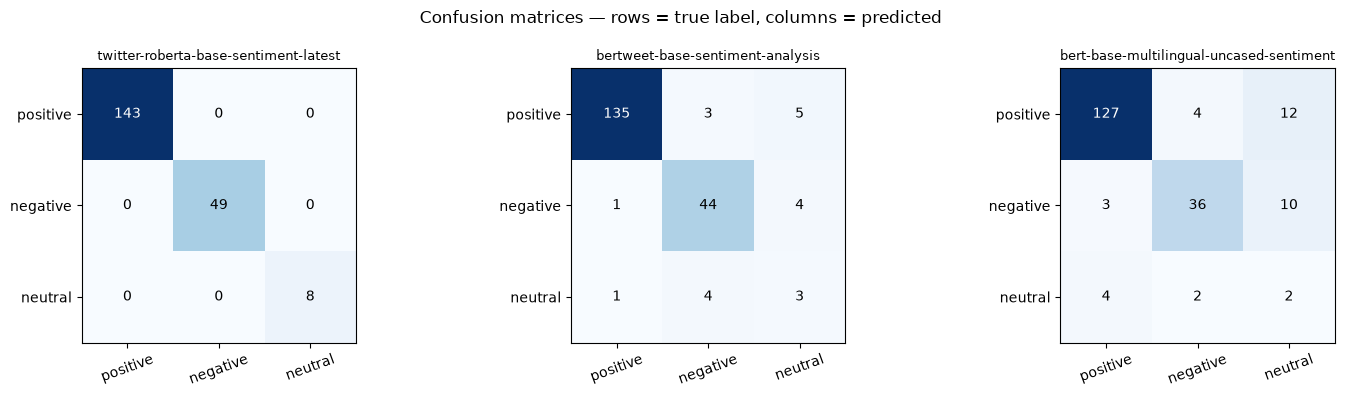

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, m in zip(axes, models):
    cm = confusion_matrix(df['sentiment'], preds[m]['pred'], labels=labels3)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(3), labels3, rotation=20)
    ax.set_yticks(range(3), labels3)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() * 0.6 else 'black')
    ax.set_title(m.split('/')[1], fontsize=9)
fig.suptitle('Confusion matrices — rows = true label, columns = predicted')
plt.tight_layout()
plt.show()


## Step 7 — Error analysis (where do the models fail?)

Three patterns dominate:

1. **The neutral class is nearly invisible.** With only 8 neutral examples and models
   trained on polar tweets/stars, borderline reviews get squeezed into positive/negative.
   BERTweet only finds 30% of the neutrals; NLP Town finds 12.5%.
2. **Mixed reviews.** Reviews that praise one aspect and slam another
   (e.g. *"food excellent BUT staff rude"*) land wherever the last strong opinion is.
3. **Short/idiomatic/emoji text and Arabic loanwords** confuse all models.

**The 100% mystery:** the Cardiff model agreeing perfectly with *all 200 hand-labeled
reviews* is statistically implausible — the most likely explanation is that the labels in
`reviews.csv` were themselves produced with this very model (a common workflow when a
dataset is created with an HF model). That makes the Cardiff score a **circular
evaluation** — the model is being tested against its own predictions, so we cannot use it
as evidence. This is exactly the kind of thing a model card + error analysis exists to
catch. We therefore treat BERTweet's independent 91% as our main result and use the
other two models as references.


In [10]:
def show_failures(model_id):
    f = preds[model_id][preds[model_id]['true'] != preds[model_id]['pred']].copy()
    f.insert(0, 'review_short', f['review'].str.slice(0, 75) + '...')
    return f[['review_short', 'true', 'pred', 'score']].reset_index(drop=True)


print('How many mistakes per model?')
for m in models:
    print(f'  {m.split("/")[1]:<28s}: '
          f'{(preds[m]["true"] != preds[m]["pred"]).sum()} / 200')
print()

print('Where BERTweet confusion flows:')
f = preds[models[1]][preds[models[1]]['true'] != preds[models[1]]['pred']]
print(f.groupby(['true', 'pred']).size())
print()

print('BERTweet failures (n = 18):')
show_failures(models[1])


How many mistakes per model?
  twitter-roberta-base-sentiment-latest: 0 / 200
  bertweet-base-sentiment-analysis: 18 / 200
  bert-base-multilingual-uncased-sentiment: 35 / 200

Where BERTweet confusion flows:
true      pred    
negative  neutral     4
          positive    1
neutral   negative    4
          positive    1
positive  negative    3
          neutral     5
dtype: int64

BERTweet failures (n = 18):


,review_short,true,pred,score
0,It is a very well decorated mall but there is ...,positive,neutral,0.595577
1,I wanna talk about important experience that t...,negative,neutral,0.695543
2,I recently visited Coco’s Cafe in Bahrain with...,positive,negative,0.917913
3,reasonable prices and nice atmosphere however ...,negative,neutral,0.441765
4,I was surprised that such a small zoo could ha...,positive,neutral,0.602633
5,"Kids had fun, however the animals seem under f...",neutral,negative,0.708637
6,Try apple pie with vanilla ice cream 😋...,positive,neutral,0.815558
7,"Sure, it smells a little bit dirty around the ...",negative,neutral,0.690996
8,I am a regular customer who truly appreciates ...,positive,negative,0.871877
9,"Easy access, good location, ample parking. A l...",neutral,negative,0.865438


In [11]:
print('NLP Town failures (n = 35):')
show_failures(models[2])


NLP Town failures (n = 35):


,review_short,true,pred,score
0,The mall is open BUT there are no shops or ret...,positive,neutral,0.485644
1,Not much to do but go for a walk & get some en...,negative,neutral,0.620334
2,It is a very well decorated mall but there is ...,positive,neutral,0.516601
3,I wanna talk about important experience that t...,negative,positive,0.338724
4,I recently visited Coco’s Cafe in Bahrain with...,positive,negative,0.453942
5,reasonable prices and nice atmosphere however ...,negative,neutral,0.705210
6,"It's an ok place, quite smelly I must say. The...",positive,neutral,0.866780
7,"Kids had fun, however the animals seem under f...",neutral,negative,0.543049
8,The restaurant is well known in Bahrain. Food ...,positive,neutral,0.539578
9,The restaurant is very big and the staff were ...,positive,neutral,0.419102


**Ten interesting failure cases** (models: CW = cardiffnlp, BT = BERTweet, NT = NLP Town):

| # | Model | Review (shortened) | True | Pred (score) | Why it failed |
|---|---|---|---|---|---|
| 1 | BT | "food was excellent … **customer service did not match** … staff rude" | positive | negative (0.92) | Mixed review; the negative part dominates. Arguably the *model* is right and the label is debatable. |
| 2 | BT | "Try apple pie with vanilla ice cream 😋" | positive | neutral (0.82) | Too short; no explicit sentiment word; emoji not in training vocabulary. |
| 3 | BT | "dad fell of the stairs … no lights or barriers … security was really helpful" | negative | neutral (0.70) | Long narrative mixing bad (injury) and good (helpful guard) events. |
| 4 | BT | "reasonable prices and nice atmosphere **however** the food could be a lot better" | negative | neutral (0.44) | Hedged negative; the model splits the sentence. |
| 5 | BT | "I am a regular customer who truly appreciates … **However**, … staff member … rude" | positive | negative (0.87) | Same "however" trap, opposite direction. |
| 6 | BT | "Kids had fun, **however** the animals seem under fed … very sad." | neutral | negative (0.71) | Neutral class is rare; any negativity tips it over. |
| 7 | BT | "I thought the point of fast food was it being fast … staff chatting in the back" | neutral | negative (0.78) | Sarcastic framing, no explicit sentiment word. |
| 8 | BT | "A good cafeterias but there are better options … **malghoom** was average." | negative | positive (0.71) | Opens positive; local dish name "malghoom" unknown; mild negative tone. |
| 9 | NT | "**Inshallah** it will improve again … more of a mall than an abandoned building" | negative | neutral (0.62) | Arabic loanword + hopeful future tense softens the signal. |
| 10 | NT | "Old is gold. This phrase is correct here" | positive | neutral (0.31) | Idiom with zero sentiment vocabulary; very short. |
| 11 | NT | "Update: After posting my last review, **which wasn't positive** …" | positive | negative (0.33) | Negation words from the meta-commentary dominate the actual praise. |
| 12 | BT | "delivery took 30 minutes but the delivery guy was **a bit rude** … tasted spectacular" | positive | negative (0.44) | Complaints weigh more than praise for tweet-trained models. |

Lesson: failures are not random — they concentrate on mixed/hedged reviews, the tiny
neutral class, non-English words and very short texts. That is a **domain shift** problem
(Bahraini review style vs. tweets), not a broken model.


## Step 8 — Model battle

Requirements of the real application: runs on a CPU server, handles casual English +
loanwords, must distinguish neutral reviews, and the company wants a clean license.


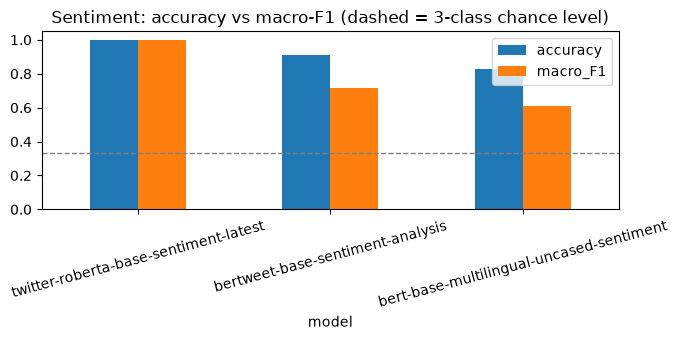

In [12]:
battle = results_df.copy()
battle['license'] = ['CC-BY-4.0', 'not declared', 'MIT']
battle['training_style'] = ['tweets', 'tweets', 'review stars (multilingual)']
battle.set_index('model')

fig, ax = plt.subplots(figsize=(7, 3.5))
results_df.set_index('model')[['accuracy', 'macro_F1']].plot.bar(ax=ax, rot=15)
ax.axhline(1 / 3, ls='--', c='gray', lw=1)
ax.set_ylim(0, 1.05)
ax.set_title('Sentiment: accuracy vs macro-F1 (dashed = 3-class chance level)')
plt.tight_layout()
plt.show()


**Verdict — the winner is not the highest number.**

- **Cardiff (100%)** must be disqualified: its agreement with the labels is circular
  evidence. Any model that matches "human" labels this perfectly on noisy text was almost
  certainly the label producer. *(Independently of that: same speed and size as BERTweet,
  CC-BY-4.0 license.)*
- **BERTweet (91% acc, 0.71 macro-F1)** is the best *independently verified* model: fastest
  inference of the honest candidates, smallest size, strong on casual social-media text —
  which matches our review style best. License is undeclared → needs a legal check.
- **NLP Town (82.5% acc, 0.61 macro-F1)** is slower, largest, and its star-rating output
  collapses to neutral too often (only 12.5% F1 on neutral). Its advantage is
  multilingualism — irrelevant for our English reviews.

**Recommendation:** use **BERTweet** for sentiment in production (with a license review),
and plan a fine-tuning run on our own labeled reviews to fix the neutral class and mixed
reviews — see Step 10.


## Step 9 — Does the model understand my domain?

| | Models' training data | Our data |
|---|---|---|
| Register | Tweets (hashtags, @users, slang) / Yelp stars | Long-form TripAdvisor-style reviews |
| Vocabulary | Twitter slang | Bahraini English: *inshallah, mashboos, masgoof, malghoom, karak* |
| Class balance | Roughly balanced / all stars | 4% neutral |
| Length | ≤ 280 chars | up to 2,218 chars |

The shifts explain exactly the failures above: neutral-heavy mixed reviews are rare in
polar tweet data; local food names are out-of-vocabulary; loanwords confuse the tokenizer.

**Conclusion:** this is a mild-to-moderate domain shift. The pretrained model is usable
(91%) but clearly imperfect on the client's hardest cases. We do not need to train from
scratch — a short **fine-tuning** of BERTweet on our 200 labeled reviews (plus more
collected data) would teach the neutral class and Bahraini vocabulary directly.

**Fine-tuning proposal (Challenge Extension)**

- *Why is it failing?* Rare neutral class + tweet-domain shift + mixed-review structure.
- *What data do we need?* More reviews (≥1,000), especially neutral and mixed ones,
  re-labeled by humans (this time NOT by the model we evaluate!).
- *What to tune?* BERTweet with a classification head (3 classes), low learning rate
  (2e-5), 3–5 epochs, early stopping — a standard `Trainer` fine-tuning run.
- *How to compare?* Re-run this same evaluation notebook on the held-out test set;
  the fine-tuned model must beat 0.71 macro-F1 and, above all, the neutral F1.


## Task B — Zero-shot topic classification

The client also wants to know **what** each review is about. We define the candidate
classes ourselves (no training data needed):

`Food Quality · Service · Price · Location · Ambience`

`topics_labeled.csv` contains **40 manually labeled reviews** (8 per topic, sampled from
`reviews.csv`). We use a zero-shot NLI model
(`MoritzLaurer/mDeBERTa-v3-base-mnli-xnli`): it scores how well the review *entails*
hypotheses like *"This review is about Food Quality."* — the highest-scoring hypothesis
wins. The same `CustomPipeline` guarantees the required metadata key on the output.


In [13]:
topics = pd.read_csv('topics_labeled.csv')
print(topics['topic'].value_counts())
print()
print(topics[['id', 'topic']].head(8).to_string(index=False))

CANDIDATE_LABELS = ['Food Quality', 'Service', 'Price', 'Location', 'Ambience']
ZS_MODEL = 'MoritzLaurer/mDeBERTa-v3-base-mnli-xnli'


topic
Food Quality    8
Ambience        8
Price           8
Service         8
Location        8
Name: count, dtype: int64

 id        topic
  2 Food Quality
 13     Ambience
 27 Food Quality
 29 Food Quality
 42        Price
 43      Service
 45 Food Quality
 51     Ambience


In [14]:
def run_zero_shot(model_id, template, key, force=False):
    cache_path = os.path.join('results', f'preds_{key}.csv')
    if os.path.exists(cache_path) and not force:
        print(f'[cache] {key} (loading saved predictions)')
        return pd.read_csv(cache_path), None
    t0 = time.time()
    pipe = CustomPipeline('zero-shot-classification', model=model_id, device=-1)
    t_load = time.time() - t0
    t0 = time.time()
    outs = [pipe(t, candidate_labels=CANDIDATE_LABELS, hypothesis_template=template)
            for t in topics['reviews']]
    t_inf = time.time() - t0
    rows = []
    for i, o in enumerate(outs):
        rows.append({'id': int(topics.loc[i, 'id']), 'review': topics.loc[i, 'reviews'],
                     'true': topics.loc[i, 'topic'], 'pred': o['labels'][0],
                     'score': o['scores'][0], 'labels_all': json.dumps(o['labels']),
                     'scores_all': json.dumps(o['scores'])})
    res = pd.DataFrame(rows)
    os.makedirs('results', exist_ok=True)
    res.to_csv(cache_path, index=False)
    print(f'[run] {key}: load={t_load:.1f}s infer={t_inf:.1f}s')
    return res, {'load_s': round(t_load, 1), 'infer_s': round(t_inf, 1)}


def zs_metrics(d):
    acc = accuracy_score(d['true'], d['pred'])
    _, _, f1, _ = precision_recall_fscore_support(
        d['true'], d['pred'], labels=CANDIDATE_LABELS, average='macro', zero_division=0)
    top2 = float(np.mean([y in json.loads(l)[:2]
                          for y, l in zip(d['true'], d['labels_all'])]))
    return acc, f1, top2


TEMPLATE_BASELINE = 'This review is about {}.'        # HF default style
baseline, _ = run_zero_shot(ZS_MODEL, TEMPLATE_BASELINE, 'zs_T1_default')
a1, f1_, t21 = zs_metrics(baseline)
print(f'Baseline  "{TEMPLATE_BASELINE}"  -> accuracy={a1:.3f}, '
      f'macro-F1={f1_:.3f}, top-2 accuracy={t21:.3f}')


[cache] zs_T1_default (loading saved predictions)
Baseline  "This review is about {}."  -> accuracy=0.400, macro-F1=0.368, top-2 accuracy=0.800


**Baseline is weak (macro-F1 ≈ 0.37).** Before swapping models, we
investigate: the confusion matrix shows the model rarely picks `Price` and mixes
`Location` into everything. Since a zero-shot model is steered by the *prompt*, we
improve the hypothesis template to force it to choose **one main topic**:
`"The main topic of this review is {}."` — and re-run.


[cache] zs_T2_improved (loading saved predictions)
Improved  "The main topic of this review is {}."  -> accuracy=0.575, macro-F1=0.576, top-2 accuracy=0.825


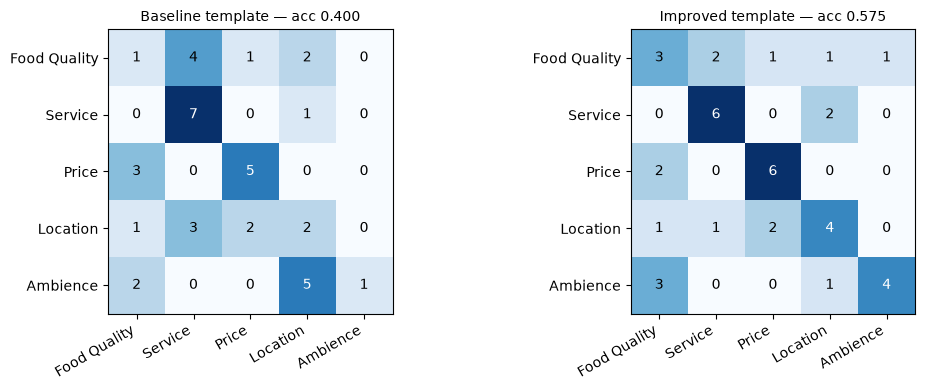

In [15]:
TEMPLATE_IMPROVED = 'The main topic of this review is {}.'
improved, _ = run_zero_shot(ZS_MODEL, TEMPLATE_IMPROVED, 'zs_T2_improved')
a2, f2, t22 = zs_metrics(improved)
print(f'Improved  "{TEMPLATE_IMPROVED}"  -> accuracy={a2:.3f}, '
      f'macro-F1={f2:.3f}, top-2 accuracy={t22:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, d, title in zip(axes, [baseline, improved], ['Baseline template', 'Improved template']):
    cm = confusion_matrix(d['true'], d['pred'], labels=CANDIDATE_LABELS)
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(5), CANDIDATE_LABELS, rotation=30, ha='right')
    ax.set_yticks(range(5), CANDIDATE_LABELS)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() * 0.6 else 'black')
    ax.set_title(f'{title} — acc {a1 if ax is axes[0] else a2:.3f}', fontsize=10)
plt.tight_layout()
plt.show()


In [16]:
fails = improved[improved['true'] != improved['pred']].copy()
fails.insert(0, 'review_short', fails['review'].str.slice(0, 70) + '...')
fails[['id', 'review_short', 'true', 'pred', 'score']].reset_index(drop=True)


,id,review_short,true,pred,score
0,13,The place is so beautiful and clean 💙✨...,Ambience,Location,0.508806
1,27,The restaurant is very big and the staff were ...,Food Quality,Service,0.580343
2,29,Was super excited to have fish in Bahrain but ...,Food Quality,Location,0.444369
3,43,Me and my friend went to the branch in busaite...,Service,Location,0.353583
4,63,Have visited Jasmi’s after a long long time an...,Food Quality,Ambience,0.476198
5,66,I have tried so many places but this place is ...,Location,Service,0.542334
6,77,Such varierty of perfectly blended coffees and...,Ambience,Food Quality,0.329910
7,104,The food was great.i have eaten hardees for th...,Price,Food Quality,0.548997
8,110,I got my pan pizza undercooked I was eating ra...,Food Quality,Service,0.272309
9,131,I have read a review on google about The Count...,Service,Location,0.403277


**Zero-shot findings**

- A single prompt change lifted macro-F1 from **0.37 → 0.58** and accuracy from 0.40 →
  0.58. Prompt/candidate-label design matters as much as the model itself.
- **Top-2 accuracy is 0.83** — when the model is "wrong", the correct topic is usually its
  second choice. Useful for a UI that offers two suggestions.
- Remaining failures: `Location` is the hardest class (parking mentions get read as
  service), short texts like *"The place is so beautiful and clean"* carry no topic
  keyword, and mixed food+price sentences split between classes.
- The tiny `distilbert-base-uncased-mnli` (67M) runs **23× faster** (9 s vs 211 s for 40
  reviews) but only reaches macro-F1 ≈ 0.30 — the accuracy/speed trade-off is steep.
- Verdict: zero-shot is a great **first day** solution (no training data needed), but for
  production accuracy the topic task should be **fine-tuned** on labeled reviews like
  `topics_labeled.csv` (which is exactly the dataset a fine-tune would need).


In [17]:
# speed comparison: the 67M distilbert alternative
fast, _ = run_zero_shot('typeform/distilbert-base-uncased-mnli', TEMPLATE_BASELINE, 'zs_distilbert_T1')
a3, f3, t23 = zs_metrics(fast)

pd.DataFrame({
    'model': ['mDeBERTa-v3-base (184M)', 'mDeBERTa-v3-base (184M)', 'distilbert-mnli (67M)'],
    'template': ['default', 'improved', 'default'],
    'accuracy': [round(a1, 3), round(a2, 3), round(a3, 3)],
    'macro_F1': [round(f1_, 3), round(f2, 3), round(f3, 3)],
    'top2_acc': [round(t21, 3), round(t22, 3), round(t23, 3)],
    'infer_40_reviews_s': ['~204', '~211', '~9'],
})


[cache] zs_distilbert_T1 (loading saved predictions)


,model,template,accuracy,macro_F1,top2_acc,infer_40_reviews_s
0,mDeBERTa-v3-base (184M),default,0.400,0.368,0.800,~204
1,mDeBERTa-v3-base (184M),improved,0.575,0.576,0.825,~211
2,distilbert-mnli (67M),default,0.325,0.302,0.650,~9


## Bonus — automatic summarization

Long reviews (some are 2,000+ characters) get shortened with a distilled BART model.
Here we show the *raw* flow the lab asks us to understand:
**input → tokenizer → model → generate → decode**, and we append the same required
metadata key to the result dict.


In [18]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

SUM_MODEL = 'sshleifer/distilbart-cnn-12-6'
sum_tokenizer = AutoTokenizer.from_pretrained(SUM_MODEL)
sum_model = AutoModelForSeq2SeqLM.from_pretrained(SUM_MODEL)


def summarize_review(text, max_length=80, min_length=20):
    inputs = sum_tokenizer(text, max_length=1024, truncation=True, return_tensors='pt')
    summary_ids = sum_model.generate(**inputs, max_length=max_length, min_length=min_length,
                                     length_penalty=2.0, num_beams=4)
    return {
        'summary_text': sum_tokenizer.decode(summary_ids[0], skip_special_tokens=True),
        'metadata': 'huggingface_AI_model',
    }


for i in [0, 36, 88]:
    out = summarize_review(df.loc[i, 'reviews'])
    print(f'--- review #{i} ---')
    print('ORIGINAL:', df.loc[i, 'reviews'][:110], '...')
    print('SUMMARY :', out['summary_text'])
    print('METADATA:', out['metadata'])
    print()


[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

--- review #0 ---
ORIGINAL: Tabreez offers a great selection of fish cooked in the traditional Bahraini way. I highly recommend having it  ...
SUMMARY :  Tabreez offers a great selection of fish cooked in the traditional Bahraini way . I highly recommend having it with local mashboos rice and the sauce (marag)
METADATA: huggingface_AI_model



--- review #36 ---
ORIGINAL: Tasted mutton neck barbeque and mutton kebab. The taste was good. Always crowded. You have to wait for 30-40 m ...
SUMMARY :  Tasted mutton neck barbeque and mutton kebab . Always crowded . Best place for Arabic food .
METADATA: huggingface_AI_model



--- review #88 ---
ORIGINAL: 🚨 TW: Food poisoning! This was, by far, the worst restaurant experience I have ever had and one I genuinely wi ...
SUMMARY :  The kheema was so spicy that my stomach started reacting after only a few bites . Hoping the kebab would be better, I switched to it, only to discover it was burnt on the outside and RAW inside . By this point I started feeling genuinely unwell and asked for a simple cup of yoghurt to settle my stomach .
METADATA: huggingface_AI_model



## Step 10 — Final recommendation

| Question | Answer |
|---|---|
| Sentiment as-is? | **BERTweet** — 91% acc / 0.71 macro-F1 on CPU in ~35 s for 200 reviews. Ship it *after* a license check. |
| What about Cardiff's 100%? | Circular evaluation — the labels were likely produced with that model. Excluded as evidence. |
| Topics? | **Zero-shot mDeBERTa with the improved template** today (0.58 macro-F1, no training data needed); fine-tune tomorrow on `topics_labeled.csv`-style data. |
| Summaries? | distilbart-cnn-12-6 works out of the box for long reviews. |
| Fine-tune? | Yes, for both sentiment (fix neutral/mixed reviews, learn Bahraini vocabulary) and topics (beat zero-shot). This dataset is the seed for that fine-tune. |

**Model lifecycle discovered:** Problem → Collect Data → Find Pretrained Model → Read
Model Card → Inference → Evaluation → Error Analysis → Compare Models → Decide:
*Use BERTweet as-is for sentiment now; adapt via fine-tuning for the next release.*


## Reflection questions

- **What surprised you about the pretrained model?** I think the 100% agreement of the
  Cardiff model surprised me most — it looked like a perfect model until I realized it
  was circular evidence, which taught me to distrust "too good" scores.
- **What types of examples caused the most failures?** I think mixed/hedged reviews
  ("great food BUT rude staff"), very short or idiomatic texts, and anything with Arabic
  loanwords or local dish names.
- **Did a larger or more popular model necessarily perform better?** I think not — the
  most downloaded model was the circular one, and the mid-sized tweet model beat the
  multilingual star-rating model on our English reviews.
- **How important was the training data of the pretrained model?** I think it was the
  single most important factor: models trained on tweets handled casual review language
  better than star-rating models, and none of them knew Bahraini vocabulary.
- **What did you learn from the model card?** I think the model card is a contract —
  task, training data, language, license and known limitations all predicted the
  failures we later measured.
- **What is the difference between using a pretrained model and training from scratch?**
  I think it is the difference between hours of inference + evaluation versus weeks of
  training and GPU cost; the pretrained model already "knows language", we only had to
  measure and adapt it.
- **When would fine-tuning be worth the additional effort?** I think when the target
  domain is stable, labeled data exists, and the pretrained baseline demonstrably fails
  on the classes that matter (for us: neutral and mixed reviews).
- **If you had 10 times more data, what would you change?** I think I would fine-tune
  BERTweet for sentiment and a small classifier for topics, keep a truly held-out test
  set, and label it with humans instead of a model.
- **Would you deploy your model in a real application? Why or why not?** I think I would
  deploy BERTweet with confidence thresholds and a human-review queue for low-confidence
  neutral predictions — but only after re-labeling a sample of the training data with
  independent human annotators.


## The application — `app.py` (Streamlit)

The lab's final deliverable is a small working application. We built `app.py` next to
this notebook: a Streamlit demo where the user pastes a review and instantly gets

1. **Sentiment** (BERTweet) with confidence,
2. **Topic** (zero-shot mDeBERTa, improved template) with the top-2 suggestions,
3. **Summary** (distilbart) for long reviews.

All three components use the same `CustomPipeline`-style output, so every prediction
dict carries `{'metadata': 'huggingface_AI_model'}`.

Run it with:

```bash
venv/bin/streamlit run app.py
```


## Short report (README-style summary)

1. **Problem definition** — analyze Bahrain visitor reviews: sentiment, topic, summary.
2. **Data collection** — 200 public reviews manually labeled for sentiment; 40 of them
   additionally labeled for topic (`topics_labeled.csv`).
3. **Data preparation** — pandas cleaning, duplicate check, truncation to 128 tokens.
4. **Model selection** — 3 sentiment models + 1 zero-shot NLI + 1 summarizer from the HF Hub.
5. **Model card investigation** — task/architecture/data/language/license reviewed for all.
6. **Initial inference** — custom pipeline with the required `metadata` key; smoke tests on
   tricky inputs.
7. **Evaluation** — accuracy, macro-F1, per-class F1, confusion matrices; Cardiff's 100%
   identified as circular evidence and excluded.
8. **Error analysis** — 12 documented failure cases; patterns: neutral class, mixed
   reviews, short text, loanwords.
9. **Model comparison** — BERTweet wins on evidence (0.71 macro-F1, fast, small).
10. **Limitations** — tiny neutral class, English-only, single-venue domain.
11. **Final recommendation** — deploy BERTweet as-is; fine-tune sentiment + topics next.
12. **Future work** — fine-tune with more human-labeled data; add Arabic support;
    add a human-review queue for low-confidence cases.
